1. What is the overall on-time performance, and what do the overall distribution of adherence look like?

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")

In [5]:
wego.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350329 entries, 0 to 350328
Data columns (total 30 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   CALENDAR_ID                350329 non-null  int64  
 1   SERVICE_ABBR               350329 non-null  int64  
 2   ADHERENCE_ID               350329 non-null  int64  
 3   DATE                       350329 non-null  object 
 4   ROUTE_ABBR                 350329 non-null  int64  
 5   BLOCK_ABBR                 350329 non-null  int64  
 6   OPERATOR                   350329 non-null  int64  
 7   TRIP_ID                    350329 non-null  int64  
 8   OVERLOAD_ID                350329 non-null  int64  
 9   ROUTE_DIRECTION_NAME       350329 non-null  object 
 10  TIME_POINT_ABBR            350329 non-null  object 
 11  ROUTE_STOP_SEQUENCE        350318 non-null  float64
 12  TRIP_EDGE                  350329 non-null  int64  
 13  LATITUDE                   35

In [6]:
timeliness = wego[['ADJUSTED_EARLY_COUNT', 'ADJUSTED_LATE_COUNT', 'ADJUSTED_ONTIME_COUNT']]

In [7]:
timeliness = timeliness.agg('sum').to_frame()

In [8]:
timeliness.columns = ['count']

In [9]:
labels = ['Early', 'Late', 'On time']
text_properties = {'fontsize': 12}

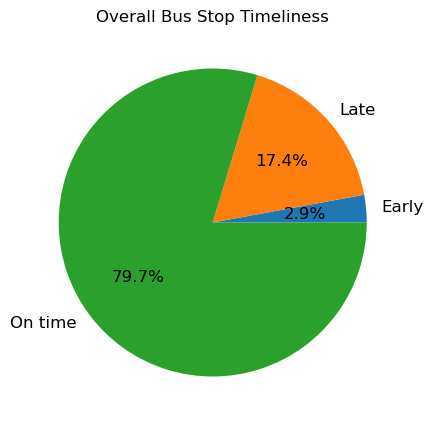

In [10]:
timeliness.plot.pie(
    y='count', 
    labels=labels, 
    autopct='%1.1f%%', 
    legend=False,
    title='Overall Bus Stop Timeliness', 
    textprops=text_properties,
    ylabel='',
    figsize=(5,5)
)
plt.savefig('../visualizations/Overall.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [13]:
adherence = wego['ADHERENCE'][wego['ADHERENCE'].isna() == False].to_frame()

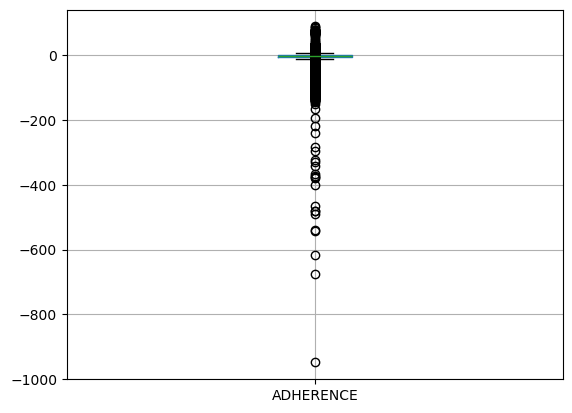

In [18]:
adherence.boxplot()
plt.savefig('../visualizations/AdherenceBoxplot.png', bbox_inches='tight', pad_inches=0.1)
plt.show()